## Desenvolvimento e avaliação de modelos de Machine Learning

### Parte 3.1 - Configuração do Ambiente e Importação do Pipeline

In [1]:
# Importa as bibliotecas necessárias
import sys
import os

# Pega o diretório atual exato onde o notebook está rodando
diretorio_atual = os.getcwd()

# Descobre a raiz do projeto
if diretorio_atual.endswith('notebooks'):
    caminho_raiz = os.path.abspath(os.path.join(diretorio_atual, '..'))
else:
    # Caso o VS Code já esteja rodando a partir da raiz
    caminho_raiz = diretorio_atual

# Adiciona a raiz aos caminhos do Python
if caminho_raiz not in sys.path:
    sys.path.append(caminho_raiz)

print(f'Caminho raiz configurado para: {caminho_raiz}.')

# Importa as funções criadas nas etapas anteriores
from src.load import carregar_dataset
from src.data_transformation import dividir_dados_treino_teste, aplicar_padronizacao

# Executa o pipeline de dados
df_raw = carregar_dataset('../data/WineQT.csv', 'quality')

# Remove o Id se existir
if 'Id' in df_raw.columns:
    df_raw = df_raw.drop('Id', axis=1)

# Feature Engineering
df_raw['total_acidity'] = df_raw['fixed acidity'] + df_raw['volatile acidity']
df_raw['sugar_to_alcohol_ratio'] = df_raw['residual sugar'] / (df_raw['alcohol'] + 1e-5)

# Define a proporção de divisão entre treino e teste
proporcao_teste = 0.2
proporcao_treino = 1 - proporcao_teste

# Divisão estratificada
x_train, x_test, y_train, y_test = dividir_dados_treino_teste(df_raw, ['Id', 'quality', 'target'], 'target', proporcao_teste, 42)

# Padronização dos dados
caminho_scaler = os.path.join(caminho_raiz, 'results', 'scaler_vinho.pkl')
x_train_scaled, x_test_scaled = aplicar_padronizacao(x_train, x_test, caminho_scaler)

# Exibe mensagens de sucesso
print('\nPipeline de dados realizado com sucesso.')
print(f'\nDados divididos em treino e teste na proporção {int(proporcao_treino * 100)}/{int(proporcao_teste * 100)}, e padronização aplicada.')



Caminho raiz configurado para: c:\z_FIAP\wine-quality-classification.

Pipeline de dados realizado com sucesso.

Dados divididos em treino e teste na proporção 80/20, e padronização aplicada.


### Parte 3.2 - Desenvolvimento do primeiro modelo - Regressão Logística

O primeiro modelo a ser treinado será o de Regressão Logística, que servirá como modelo base, por ser mais simples.

Para lidar com o desbalanceamento das classes, ativaremos o parâmetro `class_weight='balanced'`, que penaliza matematicamente o modelo com mais rigor ao errar a classe minoritária, referente aos vinhos de alta qualidade.


Relatório de Métricas: Regressão Logística
              precision    recall  f1-score   support

           0       0.94      0.81      0.87       197
           1       0.36      0.66      0.47        32

    accuracy                           0.79       229
   macro avg       0.65      0.73      0.67       229
weighted avg       0.86      0.79      0.81       229



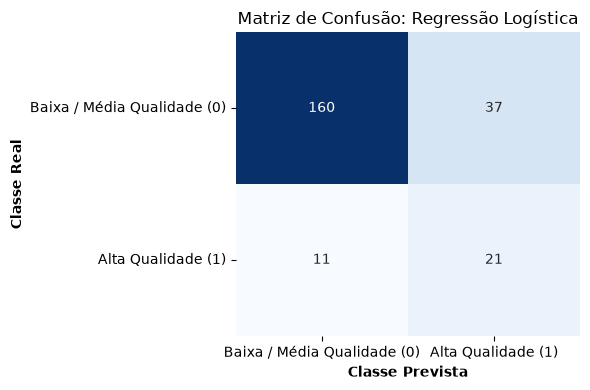

In [2]:
# Importa o modelo de Regressão Logística e a função de avaliação
from sklearn.linear_model import LogisticRegression
from src.metrics import avaliar_modelo

# Instancia o modelo com balanceamento de pesos
modelo_lr = LogisticRegression(class_weight='balanced', random_state=42)

# Treina o modelo com os dados padronizados
modelo_lr.fit(x_train_scaled, y_train)

# Realiza as previsões
y_pred_lr = modelo_lr.predict(x_test_scaled)

# Avalia e plota a matriz de confusão
rotulos = ['Baixa / Média Qualidade (0)', 'Alta Qualidade (1)']
avaliar_modelo(y_test, y_pred_lr, titulo='Regressão Logística', labels=rotulos)

### Insights sobre o modelo base - Regressão Logística

O modelo apresentou o comportamento esperado para um algoritmo linear em dados desbalanceados:
1. A **acurácia** do modelo está em um patamar realista, de **79%**. No entanto, como definimos na etapa de EDA, ela não será a métrica principal.
2. Comportamento do modelo para vinhos de *alta qualidade*:
   * Graças ao balanceamento de pesos, a taxa de **recall** foi de **66%** de os vinhos de *alta qualidade* na base de testes. Para um algoritmo simples, é um bom ponto de partida.
   * Já a **precisão** foi um ponto fraco do modelo, alcançando o percentual de somente **36%** para essa classe. A Regressão Logística assumiu uma postura "conservadora", disparando muitos falsos positivos. De todos os vinhos rotulados como de *alta qualidade*, apenas **36%** realmente o eram.
   * **Conclusão:** Como o **F1-Score** da Classe 1 (*alta qualidade*) estabeleceu a marca de **0,47**, o objetivo do próximo modelo é **ultrapassar essa marca**, **mantendo um bom recall** e **aumentando a precisão**.

### Parte 3.3 - Desenvolvimento do segundo modelo - Random Forest

Com os onjetivos de (i) superar o F1-Score e (ii) diminuir a alta taxa de falsos positivos do modelo anterior, o Random Forest será desenvolvido como o segundo modelo.

Por ser um modelo baseado em múltiplas árvores de decisão, ele consegue capturar relações não-lineares complexas entre as propriedades físico-químicas. Será mantido o ajuste de pesos balanceado para proteger a classe minoritária.


Relatório de Métricas: Random Forest
              precision    recall  f1-score   support

           0       0.95      0.92      0.93       197
           1       0.58      0.69      0.63        32

    accuracy                           0.89       229
   macro avg       0.76      0.80      0.78       229
weighted avg       0.90      0.89      0.89       229



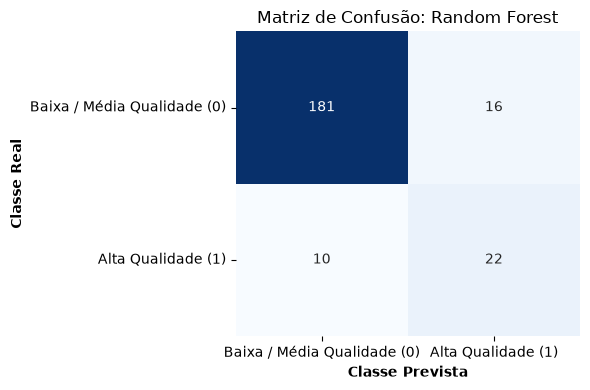

In [3]:
# Importa o modelo Random Forest e a função de avaliação
from sklearn.ensemble import RandomForestClassifier
from src.metrics import avaliar_modelo

# Instancia o modelo Random Forest com balanceamento
modelo_rf = RandomForestClassifier(
    n_estimators=100,          # Cria 100 árvores de decisão
    class_weight='balanced',   # Penaliza erros na Classe 1
    random_state=42,           
    max_depth=10               # Limita a profundidade para evitar overfitting
)

# Treina o modelo com os dados padronizados
modelo_rf.fit(x_train_scaled, y_train)

# Realiza as previsões
y_pred_rf = modelo_rf.predict(x_test_scaled)

# Avalia e plota a matriz de confusão
rotulos = ['Baixa / Média Qualidade (0)', 'Alta Qualidade (1)']
avaliar_modelo(y_test, y_pred_rf, titulo='Random Forest', labels=rotulos)

### Insights sobre o modelo alternativo - Random Forest

O modelo alternativo - **Random Forest Classifier** - superou de forma significativa o modelo base, demonstrando a superioridade de algoritmos não-lineares para este problema:

1. Foi obtido um **ganho substancial** em relação ao F1 Score de 0,47 da Regressão Logística para a Classe 1, passando a ser de **0,63**. Isso indica um modelo muito mais equilibrado e confiável para identificar vinhos de *alta qualidade*.
2. O maior triunfo do Random Forest foi o **aumento da Precisão** na Classe 1, que passou de 0,36 para 0,58. Enquanto a Regressão Logística errava de forma demasiada ao rotular vinhos de *baixa ou média qualidade* como de *alta qualidade*, o Random Forest se mostrou mais preciso, reduzindo de forma considerável os falsos positivos.

Para uma vinícola ou distribuidora, o modelo **Random Forest** reduz consideravelmente o risco de classificar um vinho de *baixa ou média qualidade* como um vinho de *alta qualidade*, mantendo uma capacidade sólida de triagem automatizada dos vinhos.

### Parte 3.4 - Comparação final e escolha do melhor modelo

Para formalizar a escolha do modelo de Machine Learning que seria levado para o ambiente de produção, consolidamos as métricas focadas na detecção de vinhos de *alta qualidade* (Classe 1) na tabela a seguir. O objetivo é visualizar o **trade-off** entre precisão e sensibilidade, utilizando o **F1-Score** como critério de desempate.

In [4]:
## Geração da tabela comparativa entre os dois modelos

# Importa as bibiliotecas necessárias
import pandas as pd
from sklearn.metrics import classification_report

# Extrai os relatórios em formato de dicionário
report_lr = classification_report(y_test, y_pred_lr, output_dict=True)
report_rf = classification_report(y_test, y_pred_rf, output_dict=True)

# Constrói a tabela focando apenas na Classe 1 (Vinhos de Alta Qualidade)
dados_comparacao = {
    'Modelo': ['Regressão Logística (Base)', 'Random Forest (Alternativo)'],
    'Precisão - Classe 1': [report_lr['1']['precision'], report_rf['1']['precision']],
    'Recall - Classe 1': [report_lr['1']['recall'], report_rf['1']['recall']],
    'F1-Score - Classe 1': [report_lr['1']['f1-score'], report_rf['1']['f1-score']]
}

df_comparacao = pd.DataFrame(dados_comparacao).set_index('Modelo')
df_comparacao_final = df_comparacao.style.format("{:.2f}").highlight_max(color='seagreen')
display(df_comparacao_final)

,Precisão - Classe 1,Recall - Classe 1,F1-Score - Classe 1
Modelo,,,
Regressão Logística (Base),0.36,0.66,0.47
Random Forest (Alternativo),0.58,0.69,0.63


### Conclusão e Decisão Técnica

A tabela comparativa apresentada valida matematicamente a escolha do **Random Forest** como o melhor modelo de Machine Learning do projeto:
* **Evolução do Modelo Base:** A transição de um modelo linear para um algoritmo de árvores múltiplas proporcionou um salto significativo no **F1-Score** - métrica principal.
* **Solução do Problema de Negócio:** Enquanto a **Regressão Logística** apresentou um bom Recall, ela falhou na Precisão, com alto risco de falsos positivos. Por sua vez, o **Random Forest** conseguiu manter a capacidade de encontrar os vinhos de *alta qualidade*, mas com taxa de erro menor.

O modelo escolhido pode ser implementado com o intuito de avaliar a qualidade dos lotes de vinho da melhor forma.